<a href="https://colab.research.google.com/github/Sruthilalitha12/Projects-Labmentixs/blob/Strava-Fitness/Strava_Fitness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STRAVA FITNESS CASE STUDY**

**Project Type** - EDA Project

**Contribution** - Individual

**NAME** - Penke Sruthi Lalitha

# **GitHub Link -**

### Installing MySQL Connector

In [ ]:
!pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   --- ------------------------------------ 1.6/16.4 MB 8.4 MB/s eta 0:00:02
   ------ --------------------------------- 2.6/16.4 MB 5.2 MB/s eta 0:00:03
   -------- ------------------------------- 3.4/16.4 MB 4.8 MB/s eta 0:00:03
   --------- ------------------------------ 3.9/16.4 MB 4.2 MB/s eta 0:00:03
   -------------- ------------------------- 6.0/16.4 MB 5.2 MB/s eta 0:00:02
   ------------------- -------------------- 8.1/16.4 MB 6.0 MB/s eta 0:00:02
   ------------------------ --------------- 10.2/16.4 MB 6.5 MB/s eta 0:00:01
   ------------------------------ --------- 12.6/16.4 MB 7.0 MB/s eta 0:00:01
   ------------------------------------ --- 14.9/16.4 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 7.5 MB/s eta 0:00:00


In [ ]:
!pip show mysql-connector-python

Name: mysql-connector-python
Version: 9.3.0
Summary: A self-contained Python driver for communicating with MySQL servers, using an API that is compliant with the Python Database API Specification v2.0 (PEP 249).
Home-page: https://dev.mysql.com/doc/connector-python/en/
Author: Oracle and/or its affiliates
Author-email: 
License: GNU GPLv2 (with FOSS License Exception)
Location: C:\Users\Sruthi Lalitha\AppData\Roaming\Python\Python312\site-packages
Requires: 
Required-by: 


In [ ]:
import mysql.connector
print("MySQL Connector installed successfully!")

MySQL Connector installed successfully!


### Connecting to MySQL Workbench

In [ ]:
import mysql.connector
import pandas as pd
db = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Apple@1299",
    database="strava"
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


### Installing pandas

In [ ]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import pandas as pd
print(pd.__version__)

2.2.2


### Installing sqlalchemy

In [ ]:
!pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


## Importing Libraries

In [ ]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#connect to server
cnx = mysql.connector.connect(
    host = "127.0.0.1",
    port=3306,
    user="root",
    password="Apple@1299")

### Importing DATA from Database

In [ ]:
query = "SELECT * FROM strava.dailyactivity_merged"

In [ ]:
df = pd.read_sql(query,cnx)

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_15096\1565249183.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,cnx)


In [ ]:
cnx.close()

In [ ]:
df.shape

(216, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        216 non-null    int64  
 1   ActivityDate              216 non-null    object 
 2   TotalSteps                216 non-null    int64  
 3   TotalDistance             216 non-null    float64
 4   TrackerDistance           216 non-null    float64
 5   LoggedActivitiesDistance  216 non-null    int64  
 6   VeryActiveDistance        216 non-null    float64
 7   ModeratelyActiveDistance  216 non-null    float64
 8   LightActiveDistance       216 non-null    float64
 9   SedentaryActiveDistance   216 non-null    int64  
 10  VeryActiveMinutes         216 non-null    int64  
 11  FairlyActiveMinutes       216 non-null    int64  
 12  LightlyActiveMinutes      216 non-null    int64  
 13  SedentaryMinutes          216 non-null    int64  
 14  Calories  

In [ ]:
duplicates = df.duplicated()
for d in duplicates:
    if d:
        print ("This is a duplicate")


There is no duplicate values

In [ ]:
df.groupby(by="Id").ActivityDate.nunique()

Id
1503960366    31
1624580081    31
1644430081    30
1844505072    31
1927972279    31
2022484408    31
2026352035    31
Name: ActivityDate, dtype: int64

In [ ]:
filtered_df = df
date_count = df.groupby(by="Id").ActivityDate.nunique()
for index, row in filtered_df.iterrows():
    if date_count[row["Id"]] < 5:

        filtered_df.drop(index,axis="index",inplace = True)

filtered_df.groupby(by="Id").ActivityDate.nunique()

Id
1503960366    31
1624580081    31
1644430081    30
1844505072    31
1927972279    31
2022484408    31
2026352035    31
Name: ActivityDate, dtype: int64

In [ ]:
##Analyze and Visualize

df.head(5)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,day_of_week,Energy Used
0,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,None,High
1,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,None,High
2,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,None,High
3,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,None,Medium
4,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,None,High


In [ ]:
# Generating descriptive statistics for the dataframe


df.describe()

,Id,Value
count,3.401700e+04,34017.000000
mean,2.022484e+09,79.013346
std,0.000000e+00,17.876446
min,2.022484e+09,49.000000
25%,2.022484e+09,66.000000
50%,2.022484e+09,75.000000
75%,2.022484e+09,88.000000
max,2.022484e+09,189.000000


## Visualization and Insights

### 1. Energy Used

In [ ]:
bins = [0, 5000, 10000, float('inf')]
labels = ['Low', 'Medium', 'High']

df['Energy Used'] = pd.cut(df['TotalSteps'], bins=bins, labels=labels, right=False)

In [ ]:
df['Energy Used'].value_counts()

Energy Used
Low       102
High       66
Medium     48
Name: count, dtype: int64

<Axes: xlabel='Energy Used'>

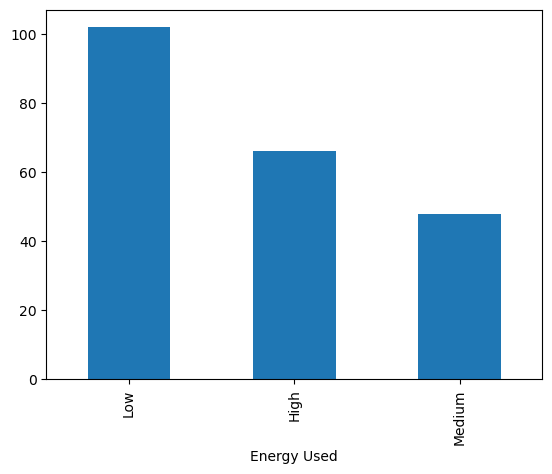

In [ ]:
df['Energy Used'].value_counts().plot(kind = 'bar')

Showing all the counts of Low, Medium, High for the Energy used.

### 2. Trends in Intensity of Workouts

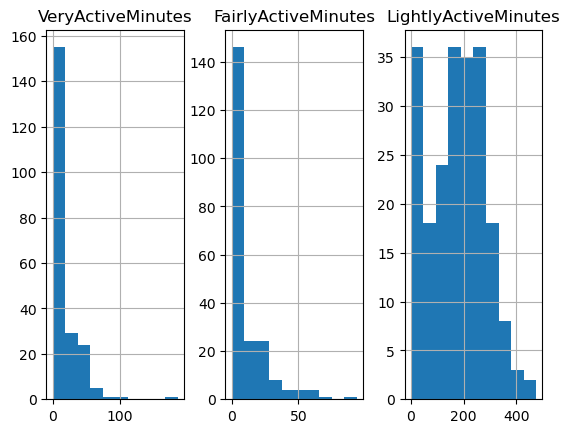

In [ ]:
fig, axes = plt.subplots(1,3)
filtered_df.hist("VeryActiveMinutes",ax=axes[0])
filtered_df.hist("FairlyActiveMinutes",ax=axes[1])
filtered_df.hist("LightlyActiveMinutes",ax=axes[2])
plt.show()

We can see right away by the postiive skewness that users are tending towards little to no intense exercise. The histogram for light exercise is far more normally distributed. We can look at the active minutes as a whole with a pie chart. Again we see that light exercise and sedentary minutes make up the vast majority of the chart. We see a clear trend toward casual use underscoring the need for a broad marketing strategy.

### 3. Activity Breakdown by Intensity

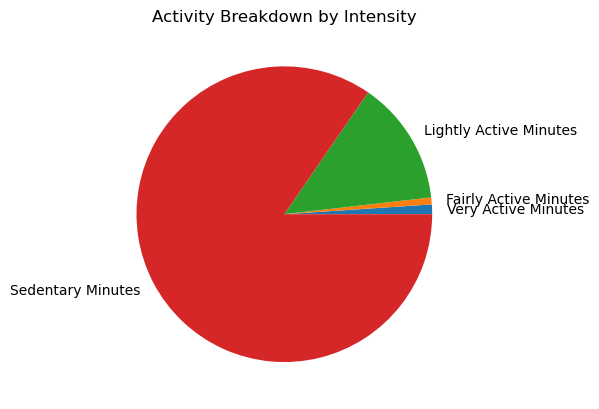

In [ ]:
veryActiveMinutes = filtered_df.loc[:,"VeryActiveMinutes"].sum()
fairlyActiveMinutes = filtered_df.loc[:,"FairlyActiveMinutes"].sum()
lightlyActiveMinutes = filtered_df.loc[:,"LightlyActiveMinutes"].sum()
sedentaryMinutes = filtered_df.loc[:,"SedentaryMinutes"].sum()

slices = [veryActiveMinutes,fairlyActiveMinutes,lightlyActiveMinutes,sedentaryMinutes]
labels = ["Very Active Minutes","Fairly Active Minutes","Lightly Active Minutes","Sedentary Minutes"]
plt.pie(slices,labels=labels)
plt.title("Activity Breakdown by Intensity")
plt.show()

Next we would like to look at the relationship between activity level and resting heart rate. We'll use the sum of FairlyActiveMinutes and VeryActiveMinutes as a proxy for activity level and see how this is correlated with minumun heart rate.

### 4. All Charts

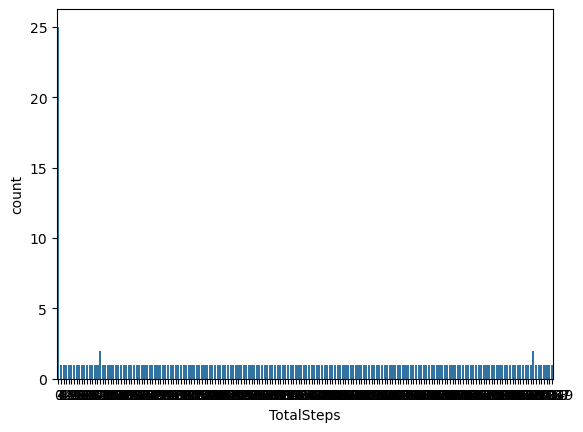

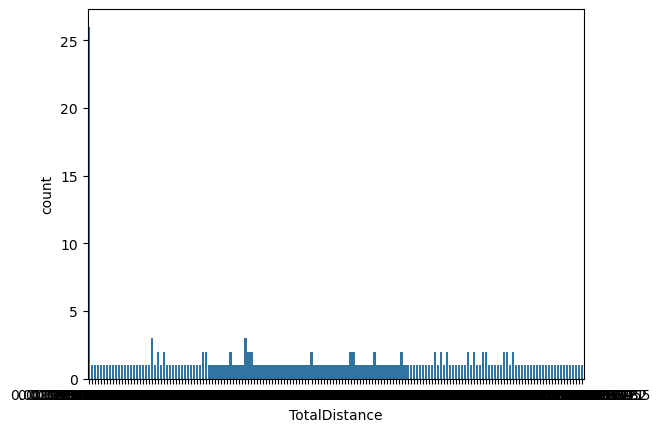

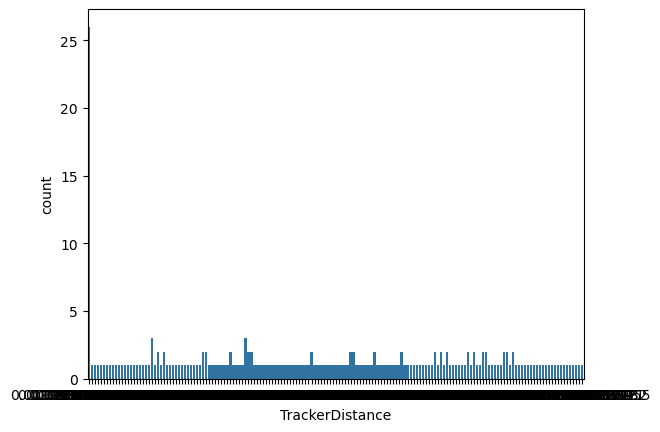

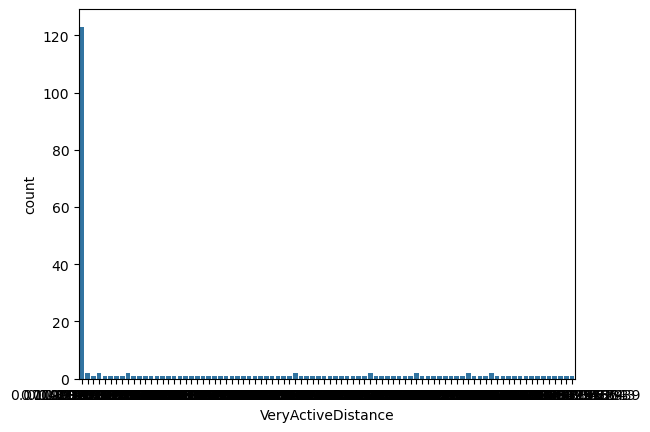

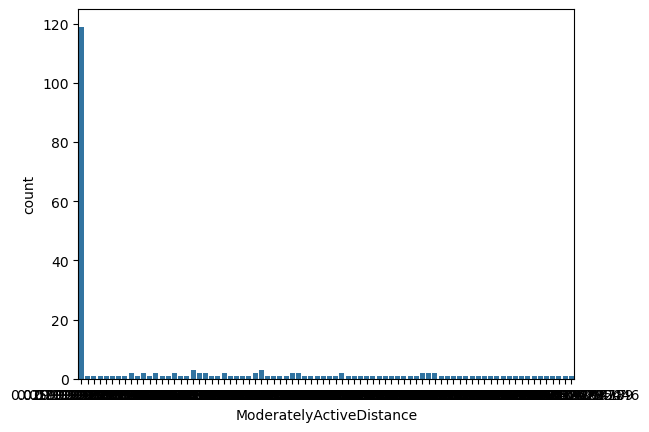

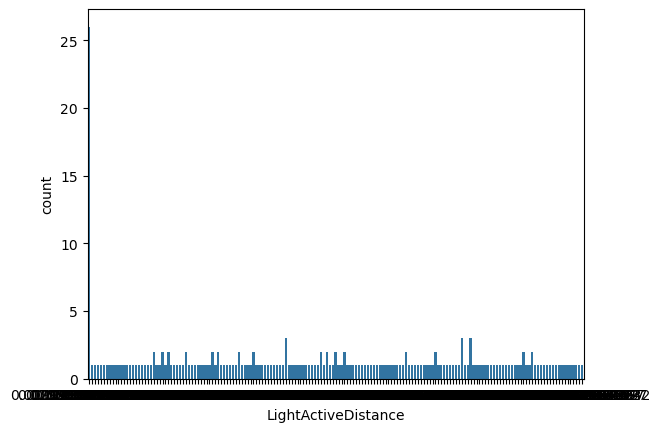

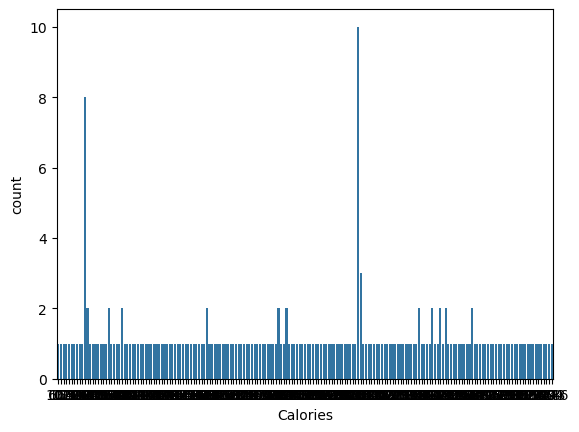

In [ ]:
for i, predictor in enumerate (df[["TotalSteps", "TotalDistance", "TrackerDistance", "VeryActiveDistance", "ModeratelyActiveDistance", "LightActiveDistance",
"Calories"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

Showing the visualizations for all the columns.

### Importing DATA

In [ ]:
import pandas as pd
import mysql.connector

cnx = mysql.connector.connect(
    host = "127.0.0.1",
    port=3306,
    user="root",
    password="Apple@1299")

query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query,cnx)

query_1 = "SELECT * FROM strava.heartrate_seconds_merged"
df_hr= pd.read_sql(query_1, cnx)  # Ensure `df` is a DataFrame

query_2 = query = "SELECT * FROM strava.sleepday_merged"
df_sleep = pd.read_sql(query_2, cnx)
print(type(df))  # Should be <class 'pandas.core.frame.DataFrame'>

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\3889614802.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,cnx)
C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\3889614802.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hr= pd.read_sql(query_1, cnx)  # Ensure `df` is a DataFrame


<class 'pandas.core.frame.DataFrame'>


C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\3889614802.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sleep = pd.read_sql(query_2, cnx)


In [ ]:
df = pd.read_sql(query,cnx)

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\1565249183.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,cnx)


In [ ]:

filtered_df = df
date_count = df.groupby(by="Id").ActivityDate.nunique()
for index, row in filtered_df.iterrows():
    if date_count[row["Id"]] < 5:

        filtered_df.drop(index,axis="index",inplace = True)

In [ ]:
df_hr.shape

(34017, 3)

In [ ]:
df_sleep.shape

(65, 5)

In [ ]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34017 entries, 0 to 34016
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Id      34017 non-null  int64 
 1   Time    34017 non-null  object
 2   Value   34017 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 797.4+ KB


In [ ]:
df_sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  65 non-null     int64 
 1   SleepDay            65 non-null     object
 2   TotalSleepRecords   65 non-null     int64 
 3   TotalMinutesAsleep  65 non-null     int64 
 4   TotalTimeInBed      65 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.7+ KB


In [ ]:
df_sleep.groupby("Id")["Id"].count()

Id
1503960366    25
1644430081     4
1844505072     3
1927972279     5
2026352035    28
Name: Id, dtype: int64

In [ ]:
duplicates = df.duplicated()
for d in duplicates:
    if d:
        print ("This is a duplicate")

There is no duplicate values

### 5. Relationship Between Activity Level and Resting Heart Rate

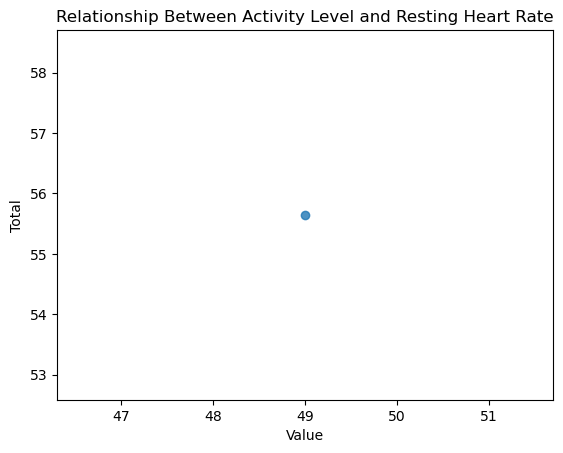

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the minimum 'Value' per 'Id'
a = df_hr.groupby("Id", as_index=False)["Value"].min()

# Compute mean activity minutes per 'Id'
b = filtered_df.groupby("Id", as_index=False)[["VeryActiveMinutes", "FairlyActiveMinutes"]].mean()

# Add a new column for total active minutes
b["Total"] = b["VeryActiveMinutes"] + b["FairlyActiveMinutes"]

# Merge both DataFrames on 'Id'
new_df = pd.merge(a, b, how="inner", on="Id")

# Plot regression
sns.regplot(x="Value", y="Total", data=new_df)
plt.title("Relationship Between Activity Level and Resting Heart Rate")
plt.show()

As we can see there is an imperfect inverse correlation indicating that activity level tends to lower resting heart rate. Since resting heart rate is a great indicator of health this could be used to advertise the benefits of using the fitness tracker.

### 6. Calories Burned vs Total Steps Taken

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\1545962470.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


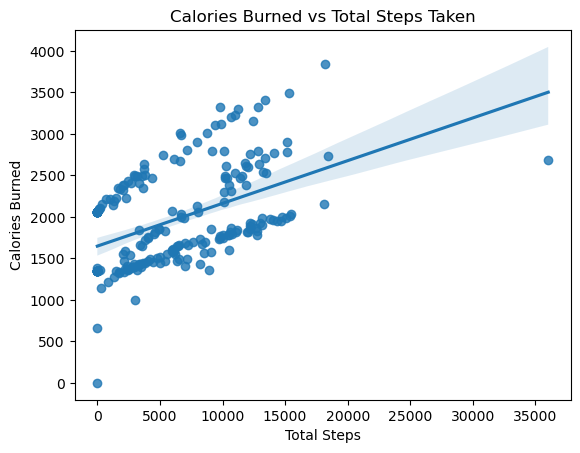

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Execute SQL query and load data into DataFrame
query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query, cnx)

# Ensure necessary columns exist
if {"TotalSteps", "Calories"}.issubset(df.columns):
    # Create regression plot
    sns.regplot(x="TotalSteps", y="Calories", data=df)
    plt.title("Calories Burned vs Total Steps Taken")
    plt.xlabel("Total Steps")
    plt.ylabel("Calories Burned")
    plt.show()
else:
    print("Error: Required columns ('TotalSteps', 'Calories') not found in DataFrame.")

In [ ]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'day_of_week'],
      dtype='object')

### 7. Calories Burned vs Very Active Minutes

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\2168376396.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


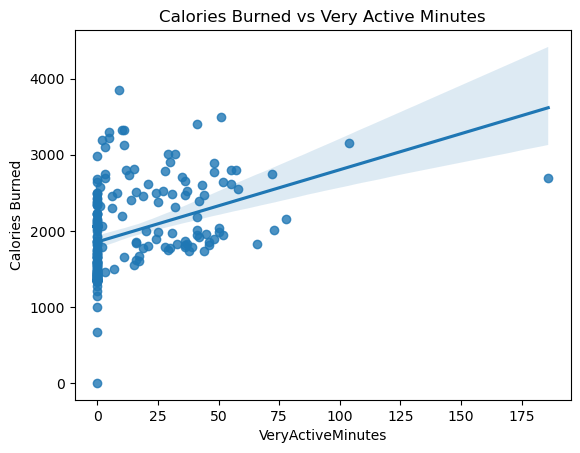

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Execute SQL query and load data into DataFrame
query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query, cnx)

# Ensure necessary columns exist
if {"VeryActiveMinutes", "Calories"}.issubset(df.columns):
    # Create regression plot
    sns.regplot(x="VeryActiveMinutes", y="Calories", data=df)
    plt.title("Calories Burned vs Very Active Minutes")
    plt.xlabel("VeryActiveMinutes")
    plt.ylabel("Calories Burned")
    plt.show()
else:
    print("Error: Required columns ('VeryActiveMinutes', 'Calories') not found in DataFrame.")

### 8. Calories Burned vs Total Distance

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_21264\2289407270.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


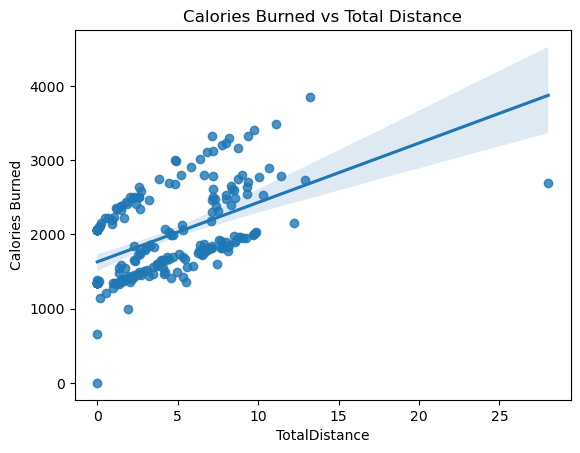

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Execute SQL query and load data into DataFrame
query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query, cnx)

# Ensure necessary columns exist
if {"TotalDistance", "Calories"}.issubset(df.columns):
    # Create regression plot
    sns.regplot(x="TotalDistance", y="Calories", data=df)
    plt.title("Calories Burned vs Total Distance")
    plt.xlabel("TotalDistance")
    plt.ylabel("Calories Burned")
    plt.show()
else:
    print("Error: Required columns ('VeryActiveMinutes', 'Calories') not found in DataFrame.")

In [ ]:
df_hr["Time"] = pd.to_datetime(df_hr["Time"], errors="coerce")  # Convert to datetime
df_hr.dropna(subset=["Time"], inplace=True)  # Remove any rows with missing timestamps
df_hr["Dayofweek"] = df_hr["Time"].dt.dayofweek  # Extract day of week

In [ ]:
missing_cols = {"HeartRate", "VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes"} - set(df_hr.columns)
print("Missing columns:", missing_cols)

Missing columns: {'LightlyActiveMinutes', 'HeartRate', 'FairlyActiveMinutes', 'VeryActiveMinutes'}


In [ ]:
df_hr.columns

Index(['Id', 'Time', 'Value', 'Dayofweek'], dtype='object')

### 9. Distribution of Mean Calories Burned

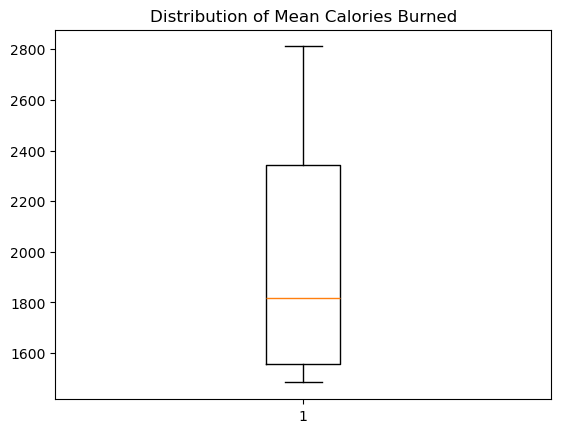

In [ ]:
calories = filtered_df.groupby(by="Id")["Calories"].mean()
plt.boxplot(calories)
plt.title("Distribution of Mean Calories Burned")
plt.show()

Here showing how many Calories users are burning on average. This will give us a good idea of how many users are interested in the product for weight loss.

So once again there is a high degree of variability in the calorie data. This bolsters the idea that BellaBeat clientele are highly varied.

In [ ]:
##Analyze and Visualize

df.head(5)

,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105
3,2022484408,4/12/2016 7:21:20 AM,103
4,2022484408,4/12/2016 7:21:25 AM,101


In [ ]:
# Generating descriptive statistics for the dataframe

df.describe()

,Id,Value
count,3.401700e+04,34017.000000
mean,2.022484e+09,79.013346
std,0.000000e+00,17.876446
min,2.022484e+09,49.000000
25%,2.022484e+09,66.000000
50%,2.022484e+09,75.000000
75%,2.022484e+09,88.000000
max,2.022484e+09,189.000000


In [ ]:
df_sleep.groupby("Id")["Id"].count()

Id
1503960366    25
1644430081     4
1844505072     3
1927972279     5
2026352035    28
Name: Id, dtype: int64

### 10. Distribution of Total Calories Burned


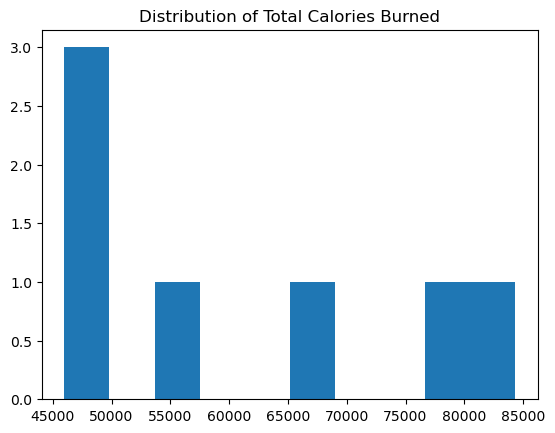

In [ ]:
gk = df.groupby(by="Id")["Calories"].sum()
gk

plt.hist(gk)
plt.title("Distribution of Total Calories Burned")
plt.show()

### 11. Average Steps Taken Through Weekdays

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_8764\71168245.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekdays, y=avg_steps, palette="viridis")


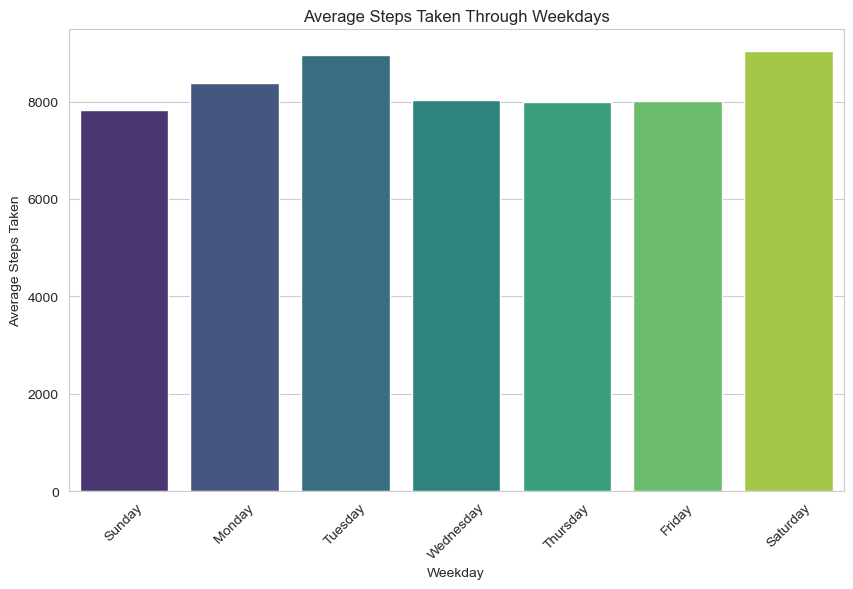

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for the average steps taken on each weekday
weekdays = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
avg_steps = [7833, 8387, 8944, 8029, 7997, 8012, 9027]

# Set style
sns.set_style("whitegrid")

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=weekdays, y=avg_steps, palette="viridis")

# Add labels and title
plt.xlabel("Weekday")
plt.ylabel("Average Steps Taken")
plt.title("Average Steps Taken Through Weekdays")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the plot
plt.show()

### 12. Active Time by Weekday

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_8764\2830375306.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


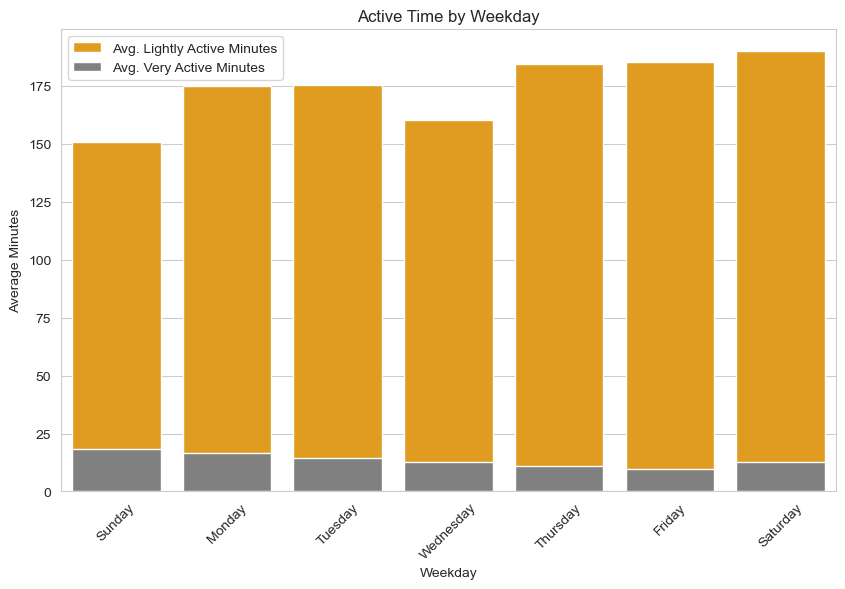

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from MySQL (already done in your code)
query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query, cnx)

# Aggregate data by weekday
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])
df["Weekday"] = df["ActivityDate"].dt.day_name()

# Compute average minutes spent in different activity categories
avg_activity = df.groupby("Weekday").agg({
    "LightlyActiveMinutes": "mean",
    "FairlyActiveMinutes": "mean",
    "VeryActiveMinutes": "mean"
}).reset_index()

# Sort by weekday order
weekday_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
avg_activity["Weekday"] = pd.Categorical(avg_activity["Weekday"], categories=weekday_order, ordered=True)
avg_activity = avg_activity.sort_values("Weekday")

# Set style and create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_activity, x="Weekday", y="LightlyActiveMinutes", color="orange", label="Avg. Lightly Active Minutes")
sns.barplot(data=avg_activity, x="Weekday", y="VeryActiveMinutes", color="gray", label="Avg. Very Active Minutes")

# Add labels and title
plt.xlabel("Weekday")
plt.ylabel("Average Minutes")
plt.title("Active Time by Weekday")
plt.legend()

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

### 13. Avg. Calories Burnt During Active Time

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_8764\762413907.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


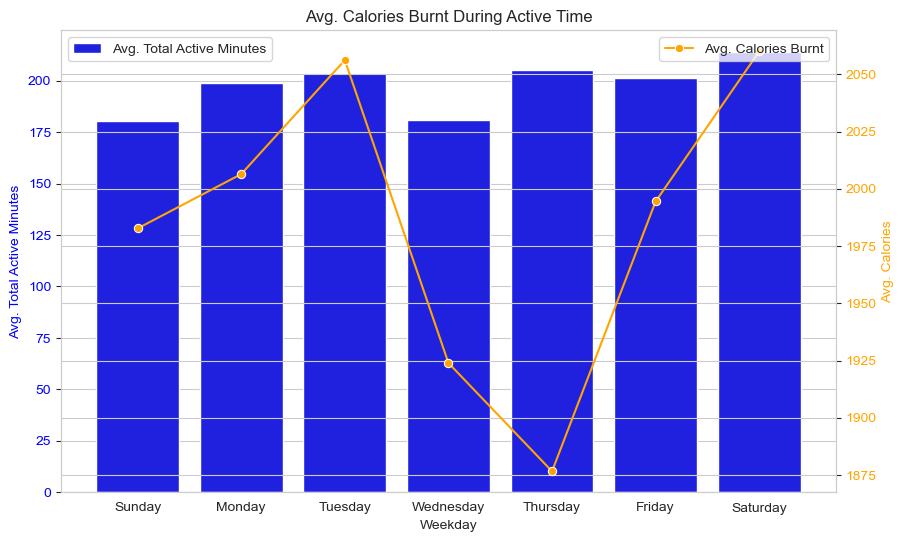

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query, cnx)

# Convert date and extract weekday
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])
df["Weekday"] = df["ActivityDate"].dt.day_name()

# Compute total active minutes
df["TotalActiveMinutes"] = df["LightlyActiveMinutes"] + df["FairlyActiveMinutes"] + df["VeryActiveMinutes"]

# Aggregate data
avg_activity = df.groupby("Weekday").agg({
    "TotalActiveMinutes": "mean",
    "Calories": "mean"
}).reset_index()

# Sort weekdays
weekday_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
avg_activity["Weekday"] = pd.Categorical(avg_activity["Weekday"], categories=weekday_order, ordered=True)
avg_activity = avg_activity.sort_values("Weekday")

# Plot bar chart for total active minutes
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=avg_activity, x="Weekday", y="TotalActiveMinutes", color="blue", ax=ax1, label="Avg. Total Active Minutes")
ax1.set_xlabel("Weekday")
ax1.set_ylabel("Avg. Total Active Minutes", color="blue")
ax1.set_title("Avg. Calories Burnt During Active Time")
ax1.tick_params(axis="y", labelcolor="blue")

# Add second Y-axis for calories burnt
ax2 = ax1.twinx()
sns.lineplot(data=avg_activity, x="Weekday", y="Calories", color="orange", marker="o", ax=ax2, label="Avg. Calories Burnt")
ax2.set_ylabel("Avg. Calories", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()

### 14. Average Steps Taken Through Weekdays

C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_8764\4024588128.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)
C:\Users\Sruthi Lalitha\AppData\Local\Temp\ipykernel_8764\4024588128.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_steps, y="Weekday", x="TotalSteps", palette="Blues", orient="h")


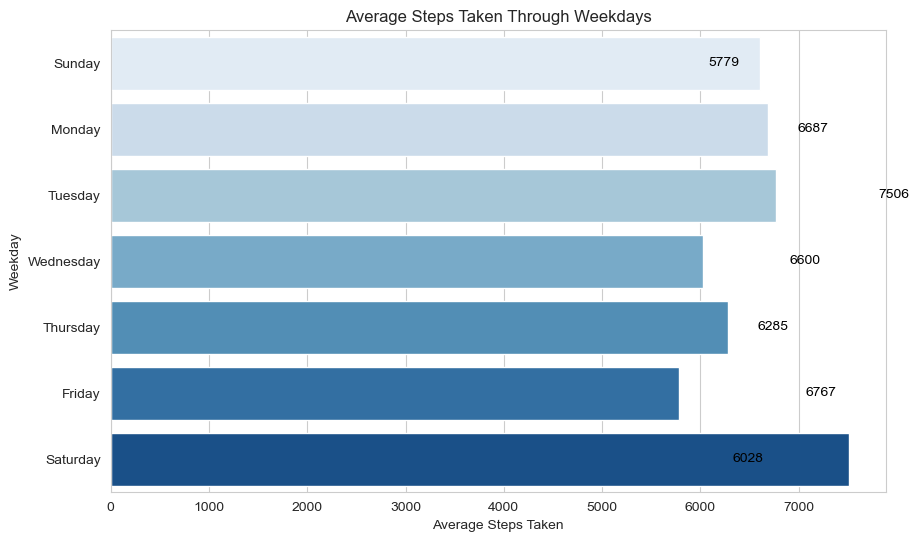

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
query = "SELECT * FROM strava.dailyactivity_merged"
df = pd.read_sql(query, cnx)

# Convert date and extract weekday
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])
df["Weekday"] = df["ActivityDate"].dt.day_name()

# Compute average steps per weekday
avg_steps = df.groupby("Weekday")["TotalSteps"].mean().reset_index()

# Sort weekdays
weekday_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
avg_steps["Weekday"] = pd.Categorical(avg_steps["Weekday"], categories=weekday_order, ordered=True)
avg_steps = avg_steps.sort_values("Weekday")

# Set style and create the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_steps, y="Weekday", x="TotalSteps", palette="Blues", orient="h")

# Add labels and title
plt.ylabel("Weekday")
plt.xlabel("Average Steps Taken")
plt.title("Average Steps Taken Through Weekdays")

# Add value annotations on bars
for index, row in avg_steps.iterrows():
    plt.text(row["TotalSteps"] + 300, index, f"{int(row['TotalSteps'])}", va="center", color="black")

# Show the plot
plt.show()

### 15. Correlation: Calories vs Steps

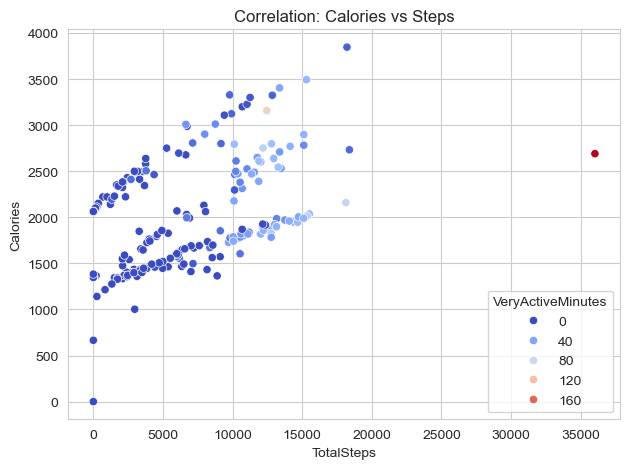

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot
ax = sns.scatterplot(x='TotalSteps', y='Calories', data=df, hue='VeryActiveMinutes', palette="coolwarm")

# Add title
plt.title('Correlation: Calories vs Steps')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

**CONCLUSION**

After performing the collection, transformation, cleaning, organisation and analysis of the given datasets, we have enough factual evidence to suggest answers to the business-related questions that were asked.
We can infer that the duration and the level of intensity of the activities performed are greatly in dependence to the amount of calories burned. METs provide a great insight on the intensity of activities performed and the amount of calories burned per minute. While most of the consumers attain adequate amounts of sleep, it is noticed that a small fraction of the users either oversleep or undersleep. Consumers are also more likely to perform low-high intensity activities in the range of 7:00 AM - 8:00PM throughout the day.

In order to design new marketing strategies to better focus on unlocking new growth oppurtunities and develop the business, we have to refer to the analysis provided above and keep those facts in mind. The recommendations I would provide to help solve this business-related scenario is shown below.

**Top Recommendations to Marketing Strategists:**

•	Highlight the MET tracking feature on the smart devices as a marketing strategy and create awareness on MET values. For it allows users to track their level of intensity of activities and provide a real time insight on how much calories they burn every minute.

•	Consumers seem to spend most of their time inactive and live a sedentary lifestyle. Notifying users through smart device notifications during the most popular time for performing activities which is between 7:00 AM - 8:00PM can remind people to exercise and live a more active lifestyle.

•	Provide app notification for users to remind them to get sufficient sleep every day and implement new sleep measurement features or products such as tracking Rapid Eye Movement (REM) sleep.

•	Consider setting daily/weekly calorie challenges and award points to users based on the top performers. Where the points can be accumulated and redeemed as a discount for their next product purchase.

